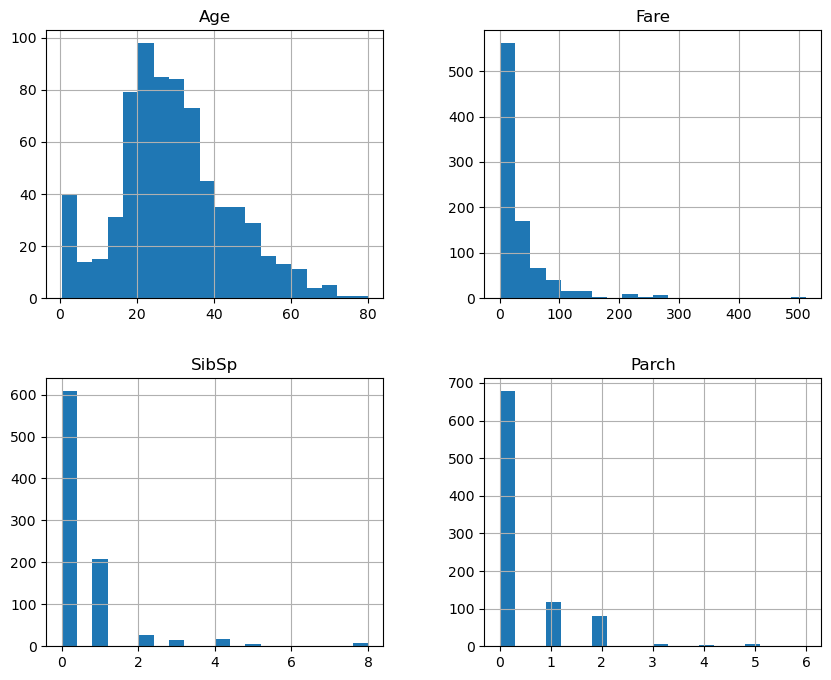

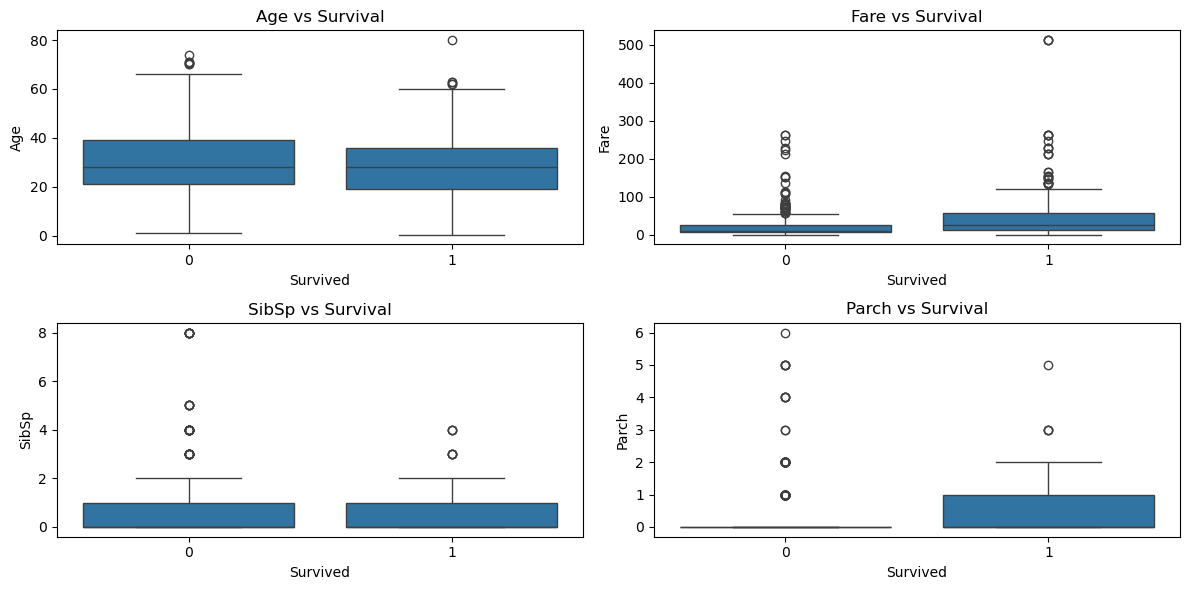

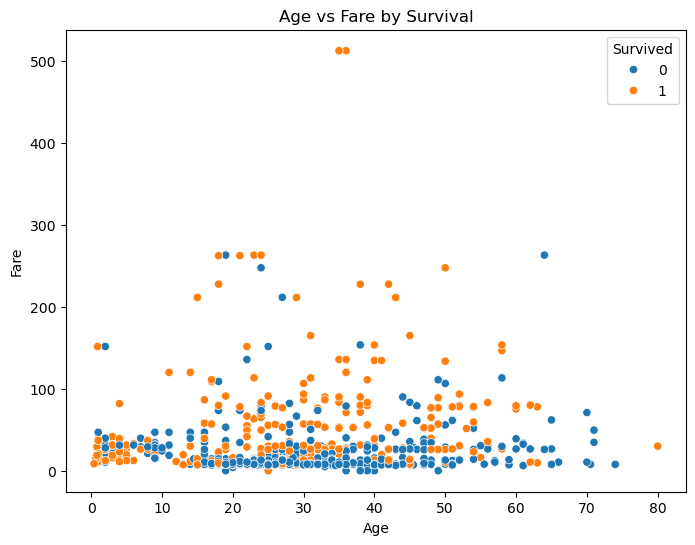

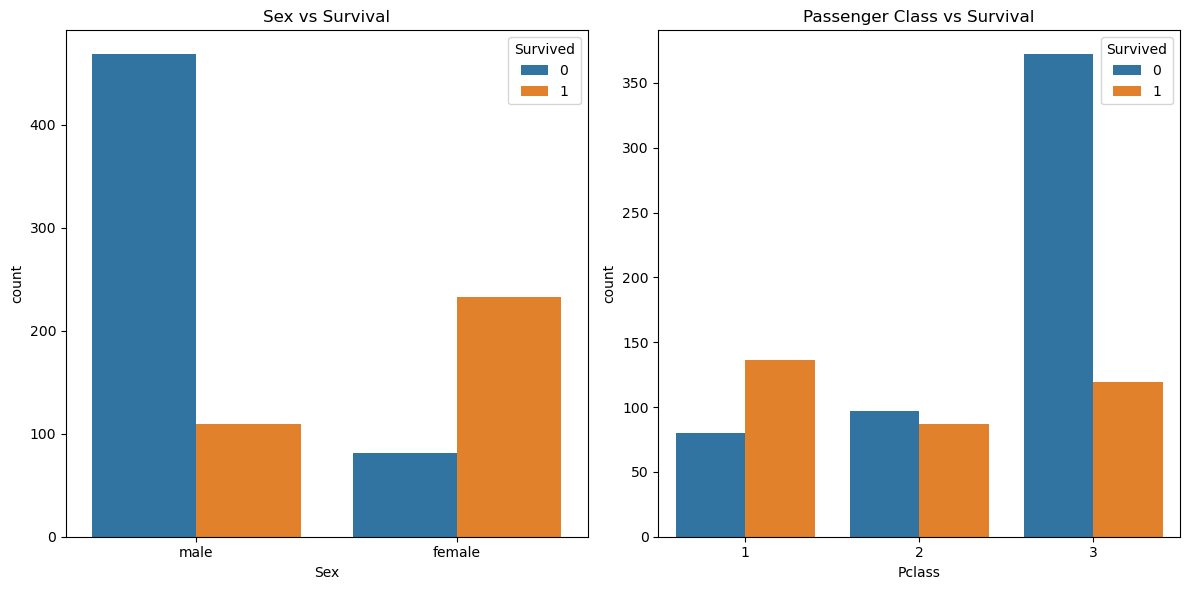

(   PassengerId  Survived  Pclass  \
 0            1         0       3   
 1            2         1       1   
 2            3         1       3   
 3            4         1       1   
 4            5         0       3   
 
                                                 Name     Sex   Age  SibSp  \
 0                            Braund, Mr. Owen Harris    male  22.0      1   
 1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
 2                             Heikkinen, Miss. Laina  female  26.0      0   
 3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
 4                           Allen, Mr. William Henry    male  35.0      0   
 
    Parch            Ticket     Fare Cabin Embarked  
 0      0         A/5 21171   7.2500   NaN        S  
 1      0          PC 17599  71.2833   C85        C  
 2      0  STON/O2. 3101282   7.9250   NaN        S  
 3      0            113803  53.1000  C123        S  
 4      0            373450   8.0500

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic datasets (train & test)
train_data = pd.read_csv("D:\\Assignments questions\\XGBM & LGBM\\Titanic_train.csv")
test_data = pd.read_csv("D:\\Assignments questions\\XGBM & LGBM\\Titanic_test.csv")

# Check first few rows of train data
train_head = train_data.head()

# Check for missing values
missing_values = train_data.isnull().sum()

# Plot histograms for numerical features
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
train_data[numerical_features].hist(figsize=(10, 8), bins=20)

# Box plots for numerical features vs survival
plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Survived', y=feature, data=train_data)
    plt.title(f'{feature} vs Survival')
plt.tight_layout()

# Scatter plot: Age vs Fare, color-coded by survival
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train_data)
plt.title("Age vs Fare by Survival")

# Bar plots for categorical features vs survival
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Sex', hue='Survived', data=train_data)
plt.title("Sex vs Survival")

plt.subplot(1, 2, 2)
sns.countplot(x='Pclass', hue='Survived', data=train_data)
plt.title("Passenger Class vs Survival")

plt.tight_layout()
plt.show()

(train_head, missing_values)


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy for preprocessing
data = train_data.copy()

# 1. Impute missing values
# Fill Age with median
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill Embarked with mode (most common value)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values), Ticket and Name (not useful for ML)
data.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

# 2. Encode categorical variables
# Label Encoding for 'Sex' (male=1, female=0)
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

# One-hot encoding for Embarked and Pclass
data = pd.get_dummies(data, columns=['Embarked', 'Pclass'], drop_first=True)

# 3. Check if missing values still exist
print(data.isnull().sum())

# Show first 5 rows of processed dataset
print(data.head())


PassengerId    0
Survived       0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
Pclass_2       0
Pclass_3       0
dtype: int64
   PassengerId  Survived  Sex   Age  SibSp  Parch     Fare  Embarked_Q  \
0            1         0    1  22.0      1      0   7.2500       False   
1            2         1    0  38.0      1      0  71.2833       False   
2            3         1    0  26.0      0      0   7.9250       False   
3            4         1    0  35.0      1      0  53.1000       False   
4            5         0    1  35.0      0      0   8.0500       False   

   Embarked_S  Pclass_2  Pclass_3  
0        True     False      True  
1       False     False     False  
2        True     False      True  
3        True     False     False  
4        True     False      True  


C:\Users\munig\AppData\Local\Temp\ipykernel_14368\1801034004.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\munig\AppData\Local\Temp\ipykernel_14368\1801034004.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [3]:
!pip install lightgbm xgboost


In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb

# ===============================
# 1. Split into features (X) and target (y)
# ===============================
X = data.drop(columns=['Survived'])
y = data['Survived']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




In [5]:
# ===============================
# 2. Build & Train LightGBM model
# ===============================
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)

# Evaluation
print("LightGBM Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1-Score:", f1_score(y_test, y_pred_lgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [6]:
# ===============================
# 3. Build & Train XGBoost model
# ===============================
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))



XGBoost Performance:
Accuracy: 0.7597765363128491
Precision: 0.7096774193548387
Recall: 0.6376811594202898
F1-Score: 0.6717557251908397

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.64      0.67        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:37:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [7]:

# ===============================
# 4. Cross-validation (for robustness)
# ===============================
lgb_cv = cross_val_score(lgb_model, X, y, cv=5, scoring='accuracy').mean()
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy').mean()

print("LightGBM CV Accuracy:", lgb_cv)
print("XGBoost CV Accuracy:", xgb_cv)

# ===============================
# 5. Hyperparameter Tuning Example (LightGBM)
# ===============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best LightGBM Params:", grid_search.best_params_)
print("Best LightGBM Score:", grid_search.best_score_)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000351 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 441
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:38:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:38:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:38:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:38:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

LightGBM CV Accuracy: 0.8115623626890967
XGBoost CV Accuracy: 0.7801519050907035
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Collect metrics in a dictionary
results = {
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgb),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgb),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


      Model  Accuracy  Precision    Recall  F1-Score
0  LightGBM  0.770950   0.718750  0.666667  0.691729
1   XGBoost  0.759777   0.709677  0.637681  0.671756


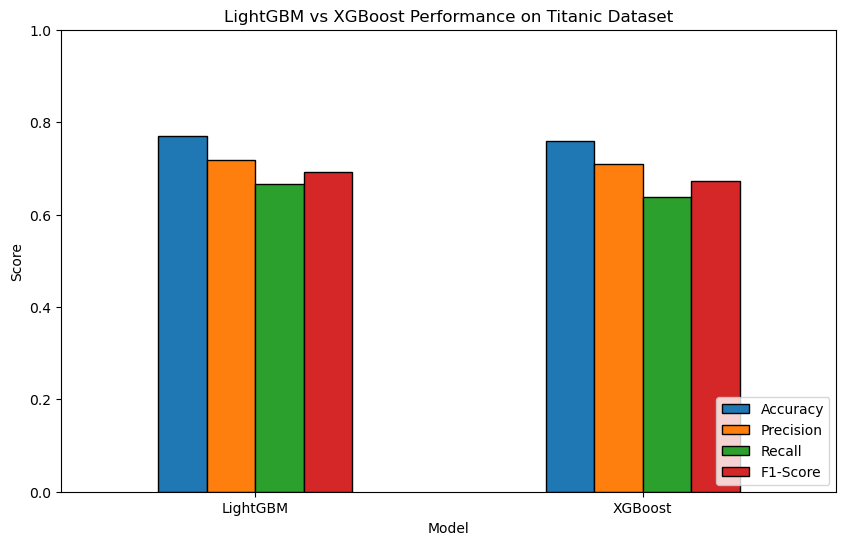

In [9]:
# Plot performance comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar", figsize=(10, 6), edgecolor="black"
)

plt.title("LightGBM vs XGBoost Performance on Titanic Dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


In [9]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],       # number of boosting rounds
    'max_depth': [3, 5, 7],               # maximum depth of trees
    'learning_rate': [0.01, 0.05, 0.1],   # step size shrinkage
    'subsample': [0.8, 1.0],              # row sampling
    'colsample_bytree': [0.8, 1.0]        # feature sampling
}

# Initialize XGBoost model
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Grid search with 3-fold cross-validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search_xgb.fit(X_train, y_train)

# Print best parameters and score
print("Best XGBoost Params:", grid_search_xgb.best_params_)
print("Best XGBoost CV Score:", grid_search_xgb.best_score_)

# Evaluate best XGBoost model on test set
best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("\nTuned XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-Score:", f1_score(y_test, y_pred_best_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_xgb))


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost CV Score: 0.8258636788048553

Tuned XGBoost Performance:
Accuracy: 0.7932960893854749
Precision: 0.8076923076923077
Recall: 0.6086956521739131
F1-Score: 0.6942148760330579

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:42:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid search with 3-fold CV
grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search_xgb.fit(X_train, y_train)

# Best params & score
print("Best XGBoost Params:", grid_search_xgb.best_params_)
print("Best XGBoost CV Score:", grid_search_xgb.best_score_)

# Evaluate tuned model on test set
best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("\nTuned XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-Score:", f1_score(y_test, y_pred_best_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_xgb))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV Score: 0.8216383599853444

Tuned XGBoost Performance:
Accuracy: 0.8044692737430168
Precision: 0.8695652173913043
Recall: 0.5797101449275363
F1-Score: 0.6956521739130435

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.95      0.86       110
           1       0.87      0.58      0.70        69

    accuracy                           0.80       179
   macro avg       0.83      0.76      0.78       179
weighted avg       0.82      0.80      0.79       179



C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:42:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],       # number of boosting rounds
    'max_depth': [3, 5, 7],               # maximum depth of trees
    'learning_rate': [0.01, 0.05, 0.1],   # step size shrinkage
    'subsample': [0.8, 1.0],              # row sampling
    'colsample_bytree': [0.8, 1.0]        # feature sampling
}

# Initialize XGBoost model
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Grid search with 3-fold cross-validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
grid_search_xgb.fit(X_train, y_train)

# Print best parameters and CV score
print("Best XGBoost Params:", grid_search_xgb.best_params_)
print("Best XGBoost CV Score:", grid_search_xgb.best_score_)

# Evaluate the best XGBoost model on test data
best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("\nTuned XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-Score:", f1_score(y_test, y_pred_best_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_xgb))


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost CV Score: 0.8258636788048553

Tuned XGBoost Performance:
Accuracy: 0.7932960893854749
Precision: 0.8076923076923077
Recall: 0.6086956521739131
F1-Score: 0.6942148760330579

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



C:\Users\munig\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:48:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
